In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import scoreatpercentile

plt.style.use("ggplot")

In [2]:
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
fund = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")
transactions = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")
portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv")

In [3]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
fund.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [5]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [6]:
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [7]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [8]:
fund.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')

In [9]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

In [10]:
portfolio.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

In [11]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

In [12]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [13]:
var_cvar = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) == 0:
        continue

    var95 = np.percentile(returns, 5)

    cvar95 = returns[returns <= var95].mean()

    var_cvar.append([
        code,
        var95,
        cvar95
    ])

var_cvar_df = pd.DataFrame(
    var_cvar,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [14]:
var_cvar_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv saved successfully.")

var_cvar_report.csv saved successfully.


In [15]:
var_cvar_df.sort_values(
    "VaR_95"
).head(10)

,amfi_code,VaR_95,CVaR_95
22,119599,-0.026859,-0.032384
17,119095,-0.026188,-0.031667
4,101207,-0.026021,-0.032459
11,118634,-0.025438,-0.032304
21,119598,-0.024507,-0.030595
39,149324,-0.023483,-0.031036
7,102886,-0.019220,-0.023251
2,100033,-0.019034,-0.023456
25,120505,-0.018892,-0.024342
16,119094,-0.018480,-0.024260


In [16]:
risk_free_rate = 0.065 / 252

rolling_sharpe = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    excess_return = group["daily_return"] - risk_free_rate

    group["rolling_sharpe"] = (
        excess_return.rolling(90).mean()
        /
        excess_return.rolling(90).std()
    ) * np.sqrt(252)

    rolling_sharpe.append(group)

rolling_sharpe_df = pd.concat(rolling_sharpe)

rolling_sharpe_df.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN


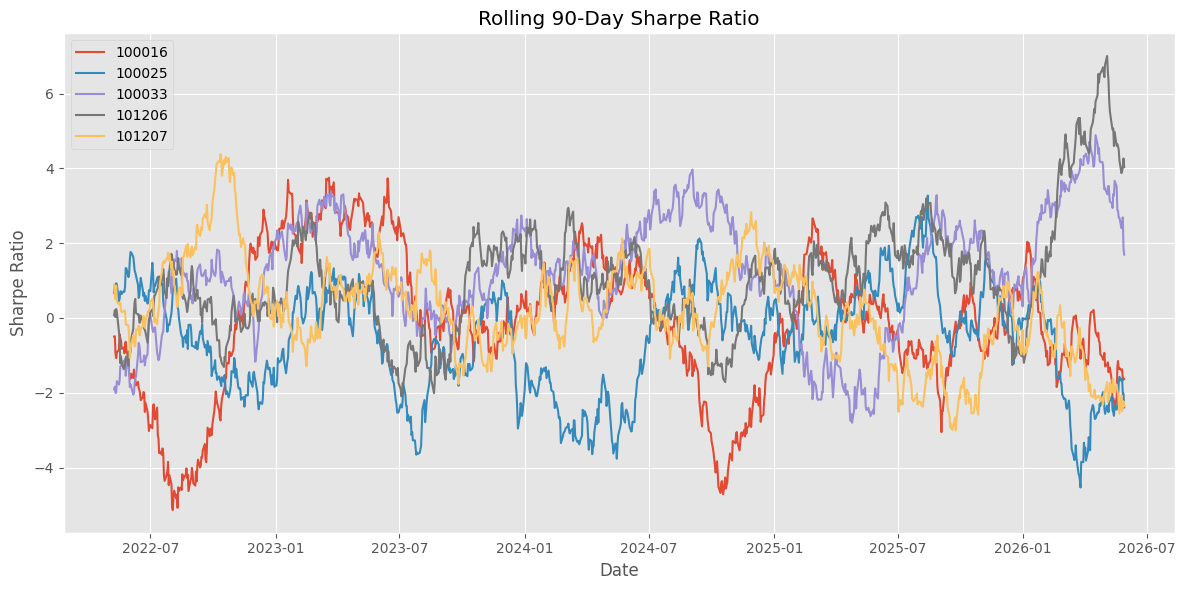

In [17]:
top5 = rolling_sharpe_df["amfi_code"].unique()[:5]

plt.figure(figsize=(12,6))

for code in top5:

    temp = rolling_sharpe_df[
        rolling_sharpe_df["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(code)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/charts/rolling_sharpe_chart.png"
)

plt.show()

In [18]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions["year"] = transactions["transaction_date"].dt.year

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,year
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [19]:
cohort = (
    transactions
    .groupby("investor_id")["year"]
    .min()
    .reset_index()
)

cohort.columns = [
    "investor_id",
    "cohort_year"
]

cohort.head()

,investor_id,cohort_year
0,INV000001,2024
1,INV000002,2024
2,INV000003,2024
3,INV000004,2024
4,INV000005,2024


In [20]:
transactions = transactions.merge(
    cohort,
    on="investor_id"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,year,cohort_year
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024,2024
1,INV003054,2024-01-07,120843,Sip,6158,Telangana,Hyderabad,T30,56+,Female,77.1,Cheque,Verified,2024,2024
2,INV003054,2024-02-16,120841,Redemption,94441,Telangana,Hyderabad,T30,56+,Female,77.1,Mandate,Verified,2024,2024
3,INV003054,2024-02-17,118634,Sip,806,Telangana,Hyderabad,T30,56+,Female,77.1,Mandate,Verified,2024,2024
4,INV003054,2024-05-20,119598,Lumpsum,384354,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024,2024


In [21]:
cohort_summary = (
    transactions
    .groupby("cohort_year")
    .agg(
        Avg_SIP=("amount_inr", "mean"),
        Total_Investment=("amount_inr", "sum"),
        Investors=("investor_id", "nunique")
    )
    .reset_index()
)

cohort_summary

,cohort_year,Avg_SIP,Total_Investment,Investors
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


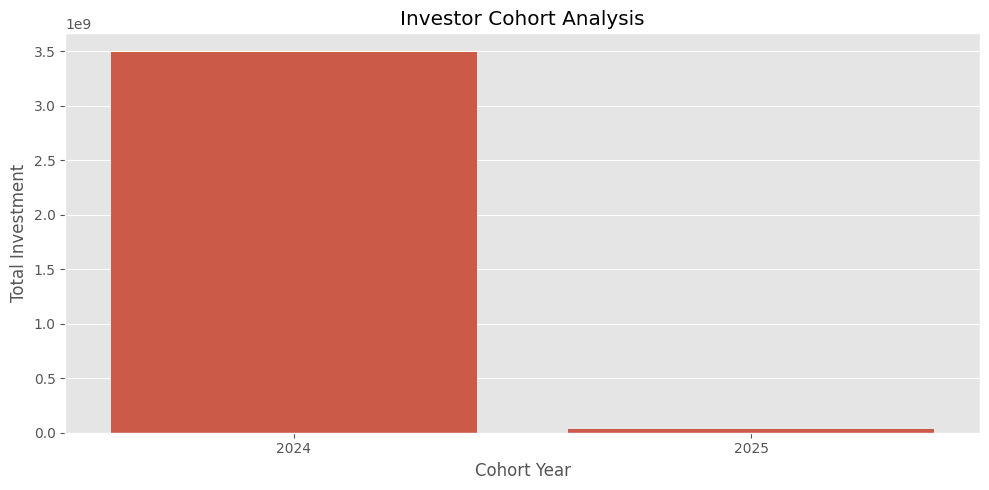

In [22]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=cohort_summary,
    x="cohort_year",
    y="Total_Investment"
)

plt.title("Investor Cohort Analysis")
plt.xlabel("Cohort Year")
plt.ylabel("Total Investment")

plt.tight_layout()

plt.savefig(
    "../reports/charts/cohort_analysis.png"
)

plt.show()

In [23]:
cohort_summary.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

print("cohort_analysis.csv saved successfully.")

cohort_analysis.csv saved successfully.


In [24]:
sip = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

sip["transaction_date"] = pd.to_datetime(
    sip["transaction_date"]
)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,year,cohort_year


In [25]:
sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,year,cohort_year


In [26]:
sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
       .diff()
       .dt.days
)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,year,cohort_year,gap_days


In [44]:
sip_count = (
    sip.groupby("investor_id")
       .size()
)

eligible = sip_count[
    sip_count >= 6
].index

sip = sip[
    sip["investor_id"].isin(eligible)
]

In [47]:
sip = sip[
    sip["investor_id"].isin(eligible)
]

In [46]:
print(sip.shape)

(9679, 15)


In [48]:
sip_gap = (
    sip.groupby("investor_id")["gap_days"]
       .mean()
       .reset_index()
)

sip_gap.columns = [
    "investor_id",
    "avg_gap_days"
]

sip_gap.head()

KeyError: 'Column not found: gap_days'

In [29]:
sip_gap["status"] = np.where(
    sip_gap["avg_gap_days"] > 35,
    "At Risk",
    "Healthy"
)

sip_gap.head()

,investor_id,avg_gap_days,status


In [30]:
sip_gap.to_csv(
    "../reports/sip_continuity.csv",
    index=False
)

print("sip_continuity.csv saved successfully.")

sip_continuity.csv saved successfully.


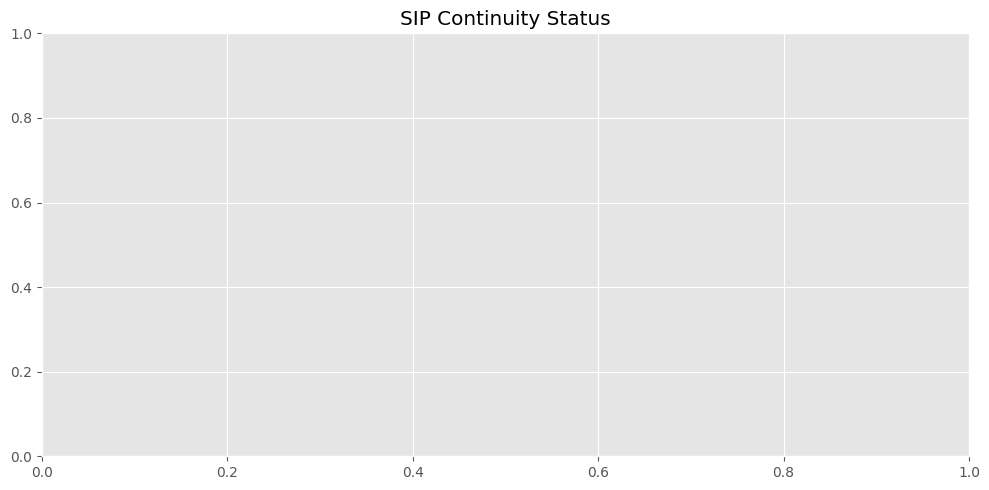

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=sip_gap,
    x="status"
)
plt.title("SIP Continuity Status")
plt.tight_layout()
plt.savefig(
    "../reports/charts/sip_continuity.png"
)
plt.show()

In [ ]:
print(sip_gap.shape)
sip_gap.head()

(0, 3)


,investor_id,avg_gap_days,status


In [33]:
sip["transaction_type"].value_counts()

Series([], Name: count, dtype: int64)

In [34]:
sip_count.describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
dtype: float64

In [35]:
transactions["transaction_type"].value_counts()

transaction_type
Sip           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

In [36]:
"SIP"

'SIP'

In [37]:
sip = transactions[
    transactions["transaction_type"] == "SIP"
]

In [38]:
sip = transactions[
    transactions["transaction_type"] == "SIP"
]

In [39]:
transactions["transaction_type"].unique()

array(['Sip', 'Redemption', 'Lumpsum'], dtype=object)

In [40]:
sip = transactions[
    transactions["transaction_type"] == "Sip"
].copy()

In [41]:
print(sip.shape)
sip.head()

(19716, 15)


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,year,cohort_year
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024,2024
1,INV003054,2024-01-07,120843,Sip,6158,Telangana,Hyderabad,T30,56+,Female,77.1,Cheque,Verified,2024,2024
3,INV003054,2024-02-17,118634,Sip,806,Telangana,Hyderabad,T30,56+,Female,77.1,Mandate,Verified,2024,2024
7,INV003054,2024-09-13,118634,Sip,9863,Telangana,Hyderabad,T30,56+,Female,77.1,Mandate,Verified,2024,2024
8,INV003054,2024-09-19,101208,Sip,6110,Telangana,Hyderabad,T30,56+,Female,77.1,Mandate,Verified,2024,2024


In [42]:
sip_count

Series([], dtype: int64)

In [49]:
print(sip.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status', 'year',
       'cohort_year'],
      dtype='object')


In [50]:
sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
       .diff()
       .dt.days
)

print(sip.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status', 'year',
       'cohort_year', 'gap_days'],
      dtype='object')


In [51]:
sip_gap = (
    sip.groupby("investor_id")["gap_days"]
       .mean()
       .reset_index()
)

sip_gap.columns = [
    "investor_id",
    "avg_gap_days"
]

sip_gap.head()

,investor_id,avg_gap_days
0,INV000004,85.400000
1,INV000008,70.400000
2,INV000010,64.800000
3,INV000011,40.166667
4,INV000012,57.000000


In [52]:
sip_gap["status"] = sip_gap["avg_gap_days"].apply(
    lambda x: "At-Risk" if x > 35 else "Active"
)

sip_gap.head()

,investor_id,avg_gap_days,status
0,INV000004,85.400000,At-Risk
1,INV000008,70.400000,At-Risk
2,INV000010,64.800000,At-Risk
3,INV000011,40.166667,At-Risk
4,INV000012,57.000000,At-Risk


In [53]:
sip_gap.to_csv(
    "../reports/sip_continuity.csv",
    index=False
)

print("sip_continuity.csv saved successfully!")

sip_continuity.csv saved successfully!


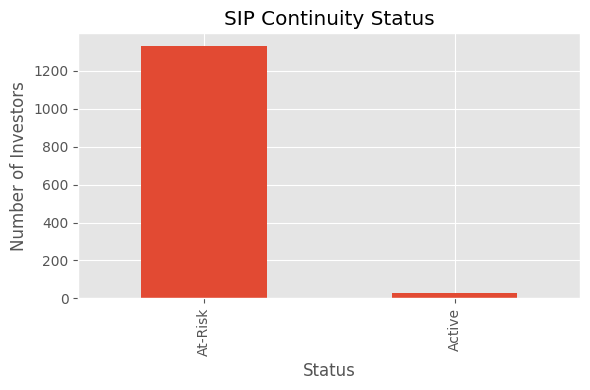

In [54]:
plt.figure(figsize=(6,4))

sip_gap["status"].value_counts().plot(kind="bar")

plt.title("SIP Continuity Status")
plt.xlabel("Status")
plt.ylabel("Number of Investors")

plt.tight_layout()

plt.savefig("../reports/charts/sip_continuity.png")

plt.show()

In [55]:
funds.columns

NameError: name 'funds' is not defined

In [57]:
fund_scorecard.columns

NameError: name 'fund_scorecard' is not defined

In [58]:
%whos

Variable            Type         Data/Info
------------------------------------------
code                int64        101207
cohort              DataFrame         investor_id  cohort_<...>\n[5000 rows x 2 columns]
cohort_summary      DataFrame       cohort_year        Avg<...>      30455243        197
cvar95              float64      -0.03103625202188441
eligible            Index        Index(['INV000004', 'INV0<...>nvestor_id', length=1362)
excess_return       Series       44850         NaN\n44851 <...>gth: 1150, dtype: float64
fund                DataFrame        amfi_code            <...>High               EC03  
group               DataFrame           amfi_code       da<...>\n[1150 rows x 5 columns]
nav                 DataFrame           amfi_code       da<...>n[46000 rows x 4 columns]
np                  module       <module 'numpy' from 'c:\<...>ges\\numpy\\__init__.py'>
pd                  module       <module 'pandas' from 'c:<...>es\\pandas\\__init__.py'>
plt                

In [59]:
fund.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')